In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
x=df.drop("Outcome",axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ac=[]

RF=RandomForestClassifier(criterion="entropy",random_state=42,n_estimators=51)
RF.fit(x_train,y_train)
y_pred=RF.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [12]:
dd=pd.read_csv('titanic.csv')

In [13]:
dd

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [15]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [16]:
dd=dd.drop(["cabin","name","ticket"],axis=1)

In [17]:
dd.isna().sum()

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

In [18]:
dd.embarked=dd.embarked.fillna(dd.embarked.mode()[0])

In [19]:
dd=dd.fillna(dd.mean(numeric_only=True))

In [20]:
dd

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.000000,0,0,211.3375,S,1
1,1,male,0.916700,1,2,151.5500,S,1
2,1,female,2.000000,1,2,151.5500,S,0
3,1,male,30.000000,1,2,151.5500,S,0
4,1,female,25.000000,1,2,151.5500,S,0
...,...,...,...,...,...,...,...,...
1304,3,female,14.500000,1,0,14.4542,C,0
1305,3,female,29.881135,1,0,14.4542,C,0
1306,3,male,26.500000,0,0,7.2250,C,0
1307,3,male,27.000000,0,0,7.2250,C,0


In [21]:
y=dd["survived"]
x=dd.drop("survived",axis=1)
x=pd.get_dummies(x)

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ac_knn=0
for i in range(27,45):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_knn:
        ac_knn=ac
        neighbor=i
print(ac_knn,">",neighbor)

0.6793893129770993 > 39


In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ac_dt=0
for i in range(1,50):
    dt=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=i)
    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac_dt,">",depth)

0.7786259541984732 > 3


In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ac_rf=0
for i in range(30,100):
    rf=RandomForestClassifier(criterion="entropy",random_state=42,n_estimators=i)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_rf:
        ac_rf=ac
        n=i
print(ac_rf,">",n)

0.7938931297709924 > 45


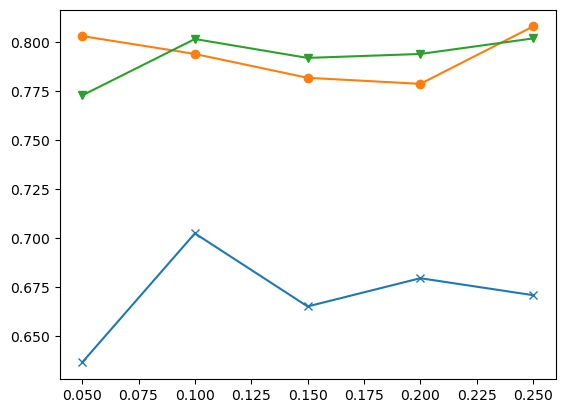

In [40]:
ac_knn=[]
ac_dt=[]
ac_rf=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    knn=KNeighborsClassifier(n_neighbors=39)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test,y_pred))
    dt=DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    ac_dt.append(accuracy_score(y_test,y_pred))
    rf=RandomForestClassifier(n_estimators=45,criterion="entropy",random_state=42)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac_rf.append(accuracy_score(y_test,y_pred))
plt.plot(test,ac_knn,marker="x")
plt.plot(test,ac_dt,marker="o")
plt.plot(test,ac_rf,marker="v")
plt.show()